# Combining Sample and Control Files (qc, blank, env blank) for Contamination Correction

In [9]:

import pandas as pd
import numpy as np
import glob, os
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from difflib import get_close_matches


# listing  the compounds samples data extracted by Nist library of unknown compound software
sample_files = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_9.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_14.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_21.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_28.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_44.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_53.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_55.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_83.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_92.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_6.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_10.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_38.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_42.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_48.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_56.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_76.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_79.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_86.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_5.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_16.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_39.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_50.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_60.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_68.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_81.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_87.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_66.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_4.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_8.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_37.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_43.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_51.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_57.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_61.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_75.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_94.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_1.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_30.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_71.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_73.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_88.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_93.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_12.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_36.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_15.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_25.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_40.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_41.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_45.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_59.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_74.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_77.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_49.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_2.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_24.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_31.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_32.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_34.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_58.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_64.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_70.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_78.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_22.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_26.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_47.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_52.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_65.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_67.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_80.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_82.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_85.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_3.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_13.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_17.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_20.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_23.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_27.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_29.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_62.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_72.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_11.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_19.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_33.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_46.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_63.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_69.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_84.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_89.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_91.csv",

]



# Replace these with  actual QC, env, blank file paths beacuse we want to remove the contamination and get the actual peaks for samples
qc_files    = glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\QC_*.csv")
env_files   = glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\env_*.csv")
blank_files = glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\blank_*.csv")

all_files = (
    [(f, "sample") for f in sample_files] +
    [(f,    "qc") for f in qc_files] +
    [(f,   "env") for f in env_files] +
    [(f, "blank") for f in blank_files]
)

# Read 
rows = []
for fp, ftype in all_files:
    df = pd.read_csv(fp)
    df["FileType"] = ftype
    df["FileName"] = fp.split("\\")[-1]
    rows.append(df)
combined = pd.concat(rows, ignore_index=True)



output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv"

# Save to CSV
combined.to_csv(output_path, index=False)

print(f"Combined dataset saved to: {output_path}")

combined.head()

Combined dataset saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Filtering True Sample Compounds

In [10]:

#  Collect compounds to exclude  blank, env, or qc compounds
exclude = combined.loc[
    combined['FileType'].isin(['blank', 'env', 'qc']),
    'Compound Name'
].unique()

# Filter sample rows and exclude those compounds
real = combined.loc[
    (combined['FileType'] == 'sample') &
    (~combined['Compound Name'].isin(exclude))
].copy()

# Group by FileName and list unique real compounds
compounds_per_sample = (
    real
    .groupby('FileName')['Compound Name']
    .unique()
    .reset_index()
    .rename(columns={'Compound Name': 'Real Compounds'})
)

#  save
print(compounds_per_sample)


         FileName                                     Real Compounds
0    sample_1.csv  [Butanal, 3-methyl-, Disulfide, dimethyl, Cycl...
1   sample_10.csv  [2-Propanone, 1-methoxy-, Butanal, 3-methyl-, ...
2   sample_11.csv  [1,3,5-Trifluorobenzene, Cyclotrisiloxane, hex...
3   sample_12.csv  [Butanal, 3-methyl-, Disulfide, dimethyl, Hexa...
4   sample_13.csv  [Isopropyl Alcohol, Benzene, Disulfide, dimeth...
..            ...                                                ...
85   sample_9.csv                                         [Dodecane]
86  sample_91.csv  [1,3,5-Trifluorobenzene, Cyclotrisiloxane, hex...
87  sample_92.csv  [2-Propanone, 1-methoxy-, Butanal, 3-methyl-, ...
88  sample_93.csv  [Butanal, 3-methyl-, Cyclotrisiloxane, hexamet...
89  sample_94.csv  [2-Propanone, 1-methoxy-, 1,3,5-Trifluorobenze...

[90 rows x 2 columns]


# Checking the presence of known potato aroma compounds

In [11]:


# Top 20 Potato Aroma Volatiles (our refrence)
potato_aromas = [
    "Hexanal",
    "Nonanal",
    "Pentanal",
    "2-Methylbutanal",
    "3-Methylbutanal",
    "1-Octen-3-ol",
    "Benzaldehyde",
    "1-Phenylethanol",
    "Methional",
    "Dimethyl trisulfide",
    "Furfural",
    "2,3-Butanedione",  
    "Ethyl butanoate",
    "2-Acetylpyrazine",
    "Dimethyl disulfide",
    "2-Propanone, 1-methoxy-",
    "Cyclotrisiloxane, hexamethyl-",  
    "3-Octanone",
    "Hexanol",
    "Butanal, 3-methyl-"
]

# Normalize function (lowercase, strip spaces/punctuation)
def normalize(name):
    return name.lower().replace(' ', '').replace('-', '').replace(',', '')

# Build a normalized lookup
ref_norm = { normalize(x): x for x in potato_aromas }

# Subset only the real samples
samples = combined[combined['FileType'] == 'sample'].copy()

# Flag exact matches
samples['norm_name'] = samples['Compound Name'].apply(normalize)
samples['is_aroma'] = samples['norm_name'].isin(ref_norm)

# Fuzzy‐match the rest
def fuzzy_match(n, refs, cutoff=0.8):
    matches = get_close_matches(n, refs, n=1, cutoff=cutoff)
    return matches[0] if matches else None

mask = ~samples['is_aroma']
fuzzy_hits = samples.loc[mask, 'norm_name'].map(lambda n: fuzzy_match(n, list(ref_norm)))
# mark and correct names
samples.loc[mask & fuzzy_hits.notna(), 'is_aroma'] = True
samples.loc[mask & fuzzy_hits.notna(), 'Compound Name'] = fuzzy_hits.map(ref_norm)

#  Now group by Sample  to list unique aroma compounds
aroma_per_sample = (
    samples[samples['is_aroma']]
    .groupby('FileName')['Compound Name']
    .unique()
    .reset_index(name='Aroma Compounds')
)

print(aroma_per_sample)


         FileName                                    Aroma Compounds
0    sample_1.csv  [Butanal, 3-methyl-, Cyclotrisiloxane, hexamet...
1   sample_10.csv  [2-Propanone, 1-methoxy-, Butanal, 3-methyl-, ...
2   sample_11.csv  [Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ...
3   sample_12.csv  [Butanal, 3-methyl-, Hexanal, Cyclotrisiloxane...
4   sample_13.csv  [Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ...
..            ...                                                ...
84  sample_89.csv  [Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ...
85  sample_91.csv  [Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ...
86  sample_92.csv  [2-Propanone, 1-methoxy-, Butanal, 3-methyl-, ...
87  sample_93.csv  [Butanal, 3-methyl-, Cyclotrisiloxane, hexamet...
88  sample_94.csv  [2-Propanone, 1-methoxy-, Butanal, 3-methyl-, ...

[89 rows x 2 columns]


# Most Frequently Detected Aroma Compounds Across Potato Samples

In [12]:
freq = presence_matrix.sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=freq.values[:20], y=freq.index[:20], palette='mako')
plt.title("Top 20 Most Common Aroma Compounds")
plt.xlabel("Number of Samples Present In")
plt.tight_layout()
plt.show()


NameError: name 'presence_matrix' is not defined

# Heatmap: Aroma Presence/Absence Matrix

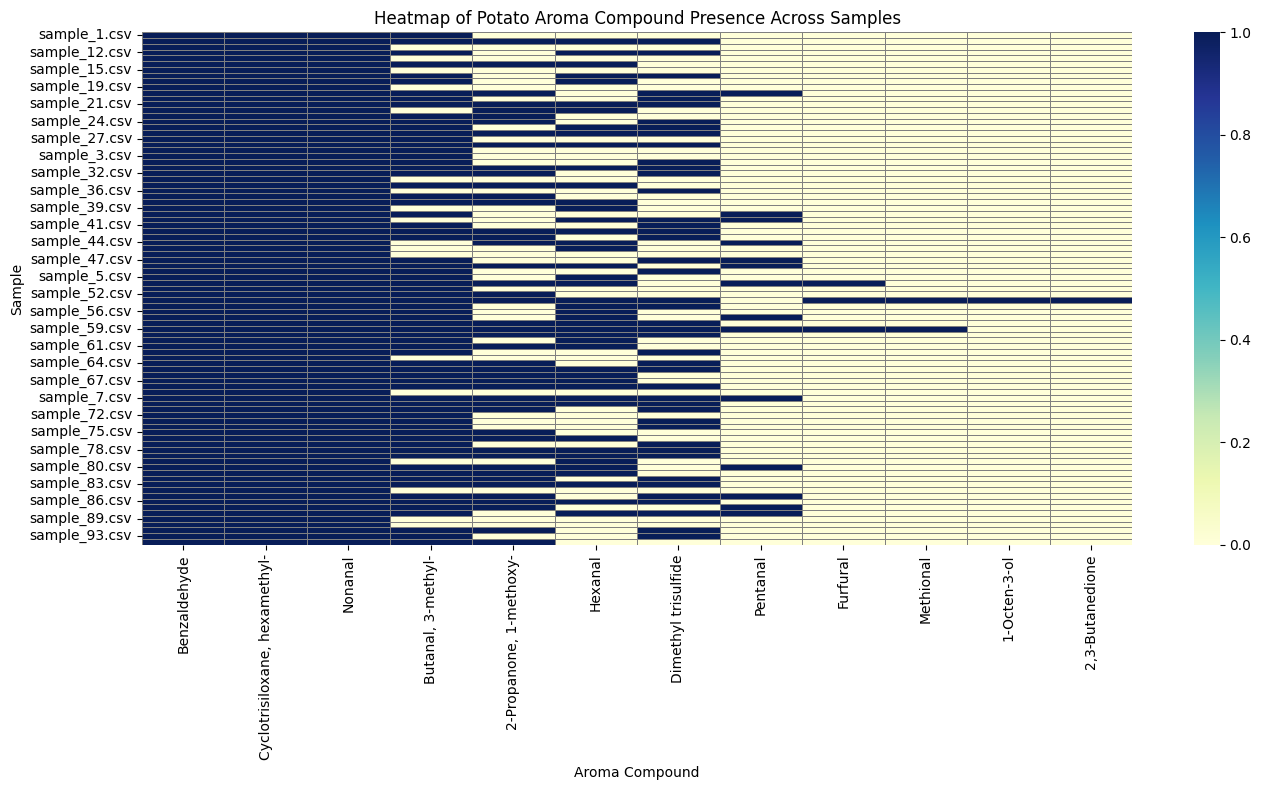

In [ ]:
# Explode list into a long format
exploded = aroma_per_sample.explode('Aroma Compounds')

# Create binary matrix: rows = samples, columns = compounds
presence_matrix = pd.crosstab(exploded['FileName'], exploded['Aroma Compounds'])

# sort columns by overall frequency
presence_matrix = presence_matrix[presence_matrix.sum().sort_values(ascending=False).index]

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(presence_matrix, cmap="YlGnBu", linewidths=0.5, linecolor='gray')
plt.title("Heatmap of Potato Aroma Compound Presence Across Samples")
plt.xlabel("Aroma Compound")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()

# Cluster the samples based on aroma compound presence using hierarchical clustering

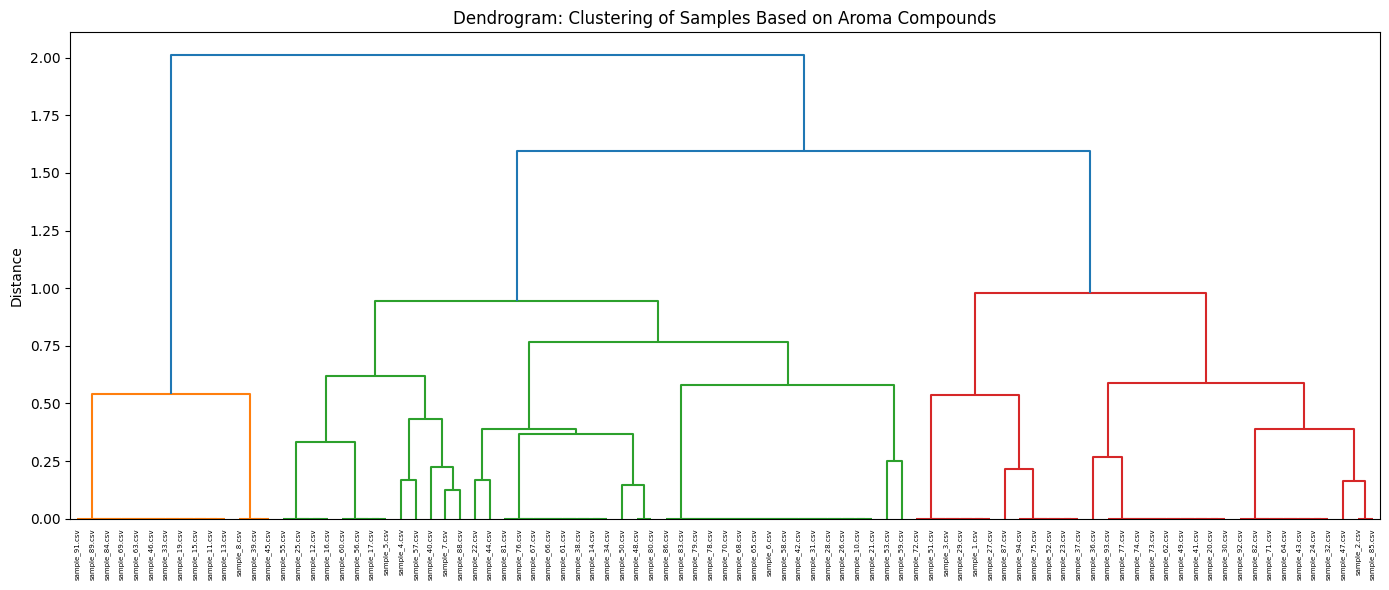

In [ ]:

# Hierarchical clustering of samples
distance_matrix = pdist(presence_matrix.values, metric='jaccard')
linkage_matrix = linkage(distance_matrix, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, labels=presence_matrix.index, leaf_rotation=90)
plt.title("Dendrogram: Clustering of Samples Based on Aroma Compounds")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Highlight top aroma compounds per sample

In [ ]:

aroma_per_sample['Sample'] = aroma_per_sample['FileName'].apply(lambda x: x)

# Explode and count top aromas per sample
top_aromas_per_sample = (
    aroma_per_sample
    .explode('Aroma Compounds')
    .groupby(['Sample', 'Aroma Compounds'])
    .size()
    .reset_index(name='Count')
    .sort_values(['Sample', 'Count'], ascending=[True, False])
)

# Select top 5 aroma compounds per sample
top5 = top_aromas_per_sample.groupby('Sample').head(5)
print("Top 5 aroma compounds per sample:")
print(top5)

# Save to CSV
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\top_aromas_per_sample.csv"
top5.to_csv(output_path, index=False)
print(f"Saved as '{output_path}'")


Top 5 aroma compounds per sample:
            Sample                Aroma Compounds  Count
0     sample_1.csv                   Benzaldehyde      1
1     sample_1.csv             Butanal, 3-methyl-      1
2     sample_1.csv  Cyclotrisiloxane, hexamethyl-      1
3     sample_1.csv                        Nonanal      1
4    sample_10.csv        2-Propanone, 1-methoxy-      1
..             ...                            ...    ...
489  sample_94.csv        2-Propanone, 1-methoxy-      1
490  sample_94.csv                   Benzaldehyde      1
491  sample_94.csv             Butanal, 3-methyl-      1
492  sample_94.csv  Cyclotrisiloxane, hexamethyl-      1
493  sample_94.csv                        Nonanal      1

[413 rows x 3 columns]
Saved as 'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\top_aromas_per_sample.csv'


# Bar Chart: Aroma Count Per Sample

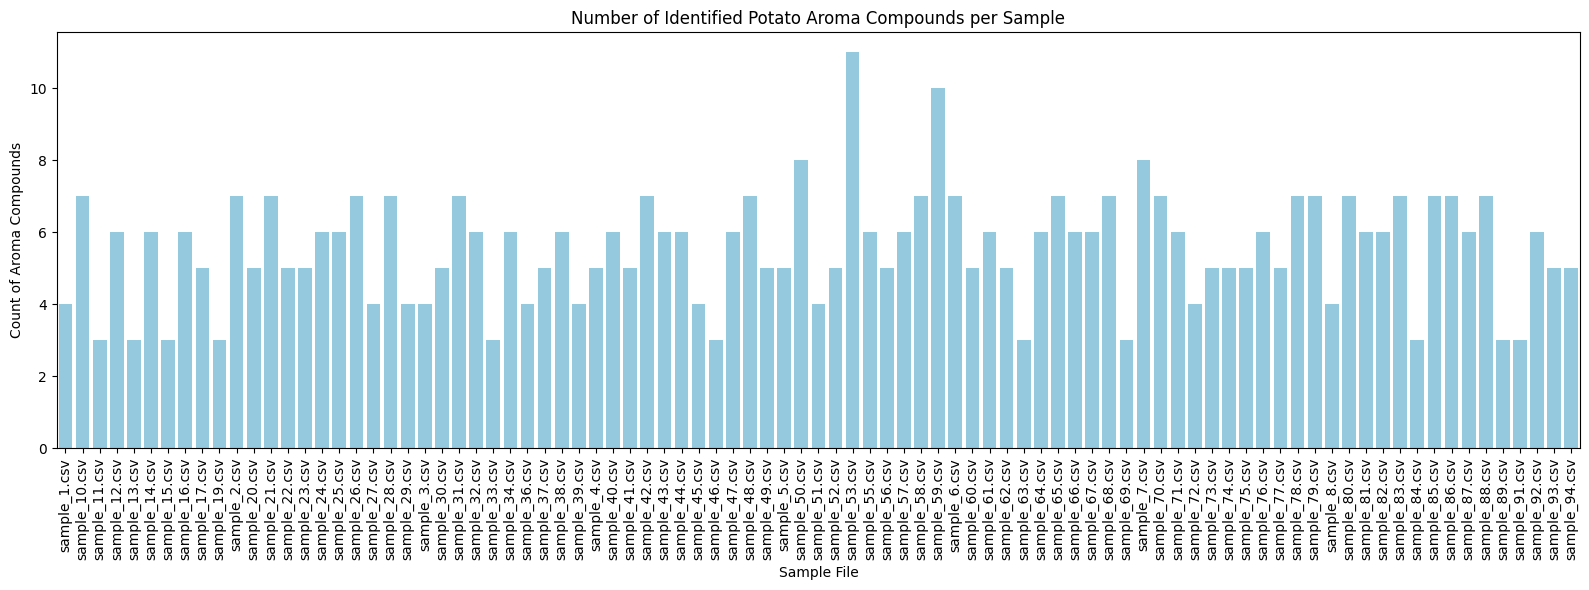

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

aroma_per_sample['Aroma Count'] = aroma_per_sample['Aroma Compounds'].apply(len)

plt.figure(figsize=(16, 6))
sns.barplot(data=aroma_per_sample, x='FileName', y='Aroma Count', color='skyblue')
plt.xticks(rotation=90)
plt.title("Number of Identified Potato Aroma Compounds per Sample")
plt.xlabel("Sample File")
plt.ylabel("Count of Aroma Compounds")
plt.tight_layout()
plt.show()

The Dendrogram shows, samples clustered closely have similar aroma profiles, while those farther apart are more distinct

# Variety vs Aroma relationship

# Map variety on samples

In [28]:


# Load the combined compound file and master mapping table
combined = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv")
master = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv")


# Filter only 'sample' rows
samples = combined[combined['FileType'] == 'sample'].copy()

# Extract sample number from filename like 'sample_11.csv' → 11
samples['SampleNumber'] = samples['FileName'].str.extract(r'(\d+)').astype(int)



# Drop rows that are Blank or QC
valid_master = master[~master['Sample'].isin(['Blank', 'QCB', 'QC1', 'QC2', 'QC3', 'QC4', 'EnvBlank'])].copy()

# Extract sample number from filenames like 'S96_11_B1_D10_T1' → 11
valid_master['SampleNumber'] = valid_master['Filename'].str.extract(r'_([0-9]+)_B')[0].astype(int)

# Extract Variety from the last part of semicolon-separated string
valid_master['Variety'] = valid_master['Sample'].str.split(';').str[-1].str.strip()

# Drop duplicates (in case of multiple entries for same SampleNumber)
sample_to_variety = valid_master[['SampleNumber', 'Variety']].drop_duplicates()

# Merge with compound dataset
merged = pd.merge(samples, sample_to_variety, on='SampleNumber', how='left')

# Save final mapped file
merged.to_csv("mapped_samples_with_varieties_complete.csv", index=False)
print(" Mapping complete. File saved as 'mapped_samples_with_varieties_complete.csv'")



merged


 Mapping complete. File saved as 'mapped_samples_with_varieties_complete.csv'


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName,SampleNumber,Variety
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv,7,ALVERSTONE R.
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv,7,ALVERSTONE R.
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv,7,ALVERSTONE R.
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv,7,ALVERSTONE R.
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv,7,ALVERSTONE R.
...,...,...,...,...,...,...,...,...,...
2272,19.063383,"Dodecanoic acid, 1-methylethyl ester",90.323965,True,C15H30O2,sample,sample_91.csv,91,TRIPLE7
2273,19.327050,Benzophenone,97.857798,True,C13H10O,sample,sample_91.csv,91,TRIPLE7
2274,20.687133,"1,3-Benzenedicarboxylic acid, bis(2-ethylhexyl...",96.889881,True,C24H38O4,sample,sample_91.csv,91,TRIPLE7
2275,21.040833,"2-Propanol, 1-chloro-, phosphate (3:1)",93.556949,True,C9H18Cl3O4P,sample,sample_91.csv,91,TRIPLE7


# Count of compounds per variety

# Jaccard Similarity Between Samples

c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


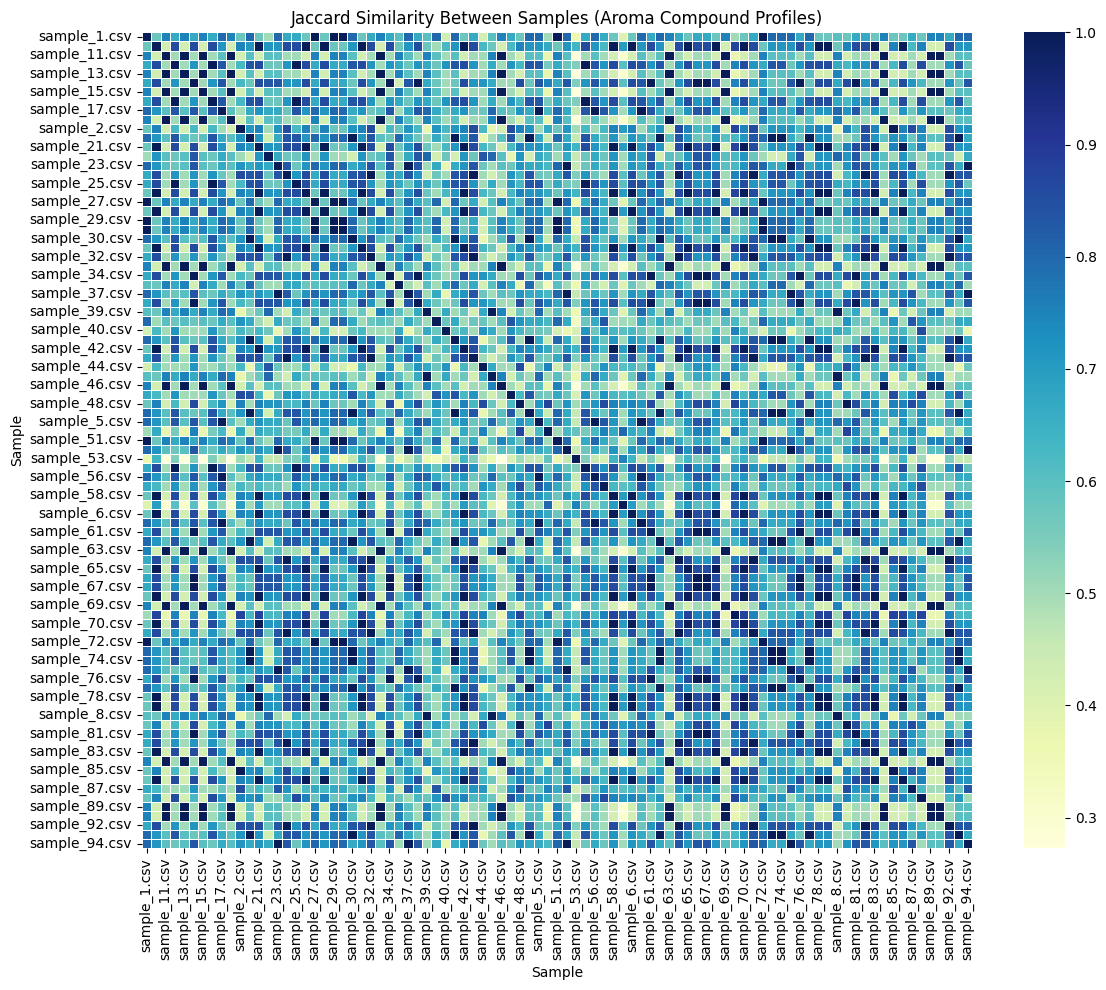

In [ ]:

from sklearn.metrics import pairwise_distances

# Load presence/absence matrix
df = pd.read_csv("C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/bio_rep1/compound_analysis/aroma_presence_matrix.csv")

# Set sample name as index
df.set_index("FileName", inplace=True)

# Ensure all values are binary
binary_df = df.astype(bool).astype(int)

# Compute Jaccard similarity 
jaccard_similarity = 1 - pairwise_distances(binary_df.values, metric="jaccard")

# Convert to DataFrame
jaccard_df = pd.DataFrame(jaccard_similarity, index=binary_df.index, columns=binary_df.index)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(jaccard_df, cmap="YlGnBu", linewidths=0.5)
plt.title("Jaccard Similarity Between Samples (Aroma Compound Profiles)")
plt.xlabel("Sample")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()


# PCA on compound presence

# Corrolation between aroma compounds